# 🧬 Gen İfade Verisiyle Kanser Riski Tespiti
## Makine Öğrenmesi Projesi

| | |
|---|---|
| **Ders** | Veri Madenciliği — 2025-2026 Bahar |
| **Proje Türü** | Dönem İçi Proje |
| **Öğrenci** | Furkan Gül |
| **Öğrenci No** | 2311505269 |
| **Tarih** | 05.06.2026 |

---

## 📋 İçindekiler

1. [Giriş ve Motivasyon](#1-giriş-ve-motivasyon)
2. [Kütüphaneler](#2-kütüphaneler)
3. [Veri Seti Yükleme ve EDA](#3-veri-seti-yükleme-ve-eda)
4. [Veri Ön İşleme](#4-veri-ön-işleme)
5. [Aşırı Öğrenme, Bias-Varyans ve K-Fold](#5-aşırı-öğrenme-bias-varyans-ve-k-fold)
6. [Model Eğitimi](#6-model-eğitimi)
7. [Model Değerlendirme](#7-model-değerlendirme)
8. [Dengesiz Sınıflar](#8-dengesiz-sınıflar)
9. [Sonuç ve Karşılaştırma](#9-sonuç-ve-karşılaştırma)
10. [Kaynakça](#10-kaynakça)

---

## 1. Giriş ve Motivasyon

### 1.1 Problemin Tanımı

Kanser, dünya genelinde en fazla ölüme yol açan hastalıklardan biridir. Gen ifadesi (gene expression) verileri, hücrelerin hangi genleri ne kadar aktif kullandığını gösterir. Bu veriler, tümörlü ve sağlıklı dokuları birbirinden ayırt etmek için kullanılabilir.

Bu projede iki adet gen ifadesi değişkeni (Gen1, Gen2) kullanarak bireyin **kanser riskini** (0 = Sağlıklı, 1 = Kanser) tahmin eden makine öğrenmesi modelleri geliştireceğiz.

### 1.2 Projenin Amacı

- ✅ gen_expression.csv veri seti üzerinde ikili sınıflandırma
- ✅ KNN, Karar Ağaçları, Naive Bayes ve K-Means algoritmalarını uygulama
- ✅ Bias-Varyans, Aşırı Öğrenme, K-Fold ve model değerlendirme kavramlarını inceleme
- ✅ ROC-AUC, Karmaşıklık Matrisi ve Benzerlik İndeksleri ile modelleri karşılaştırma

---

## 2. Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay,
    jaccard_score, f1_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("Tüm kütüphaneler yüklendi ✓")

Tüm kütüphaneler yüklendi ✓


## 3. Veri Seti Yükleme ve EDA

### 3.1 Veri Seti Hakkında

| Sütun | Açıklama | Tip |
|:---|:---|:---:|
| `Gen1` | Birinci gen ifadesi değeri | Sayısal |
| `Gen2` | İkinci gen ifadesi değeri | Sayısal |
| `Kanser` | **0 = Sağlıklı, 1 = Kanser** | İkili (Hedef) |

In [2]:
# Veriyi yükle
df = pd.read_csv('gene_expression.csv')

print("=" * 45)
print("VERİ SETİ ÖZETİ")
print("=" * 45)
print(f"Satır sayısı  : {df.shape[0]}")
print(f"Sütun sayısı  : {df.shape[1]}")
print(f"\nSınıf Dağılımı:")
print(f"  Sağlıklı (0) : {(df['Kanser']==0).sum()} kişi ({(df['Kanser']==0).mean():.1%})")
print(f"  Kanser   (1) : {(df['Kanser']==1).sum()} kişi ({(df['Kanser']==1).mean():.1%})")
print("=" * 45)
df.head()

VERİ SETİ ÖZETİ
Satır sayısı  : 3000
Sütun sayısı  : 3

Sınıf Dağılımı:
  Sağlıklı (0) : 1500 kişi (50.0%)
  Kanser   (1) : 1500 kişi (50.0%)


,Gen1,Gen2,Kanser
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


### 3.2 Temel İstatistikler

In [3]:
# Temel istatistikler
print("Temel İstatistikler:")
print(df.describe().round(3))

print("\nEksik Değer Kontrolü:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ Eksik değer yok.")
else:
    print(missing[missing > 0])

Temel İstatistikler:
           Gen1      Gen2  Kanser
count  3000.000  3000.000  3000.0
mean      5.600     5.410     0.5
std       1.828     1.729     0.5
min       1.000     1.000     0.0
25%       4.300     4.000     0.0
50%       5.600     5.400     0.5
75%       6.900     6.700     1.0
max      10.000    10.000     1.0

Eksik Değer Kontrolü:
✅ Eksik değer yok.


### 3.3 Görsel Analiz

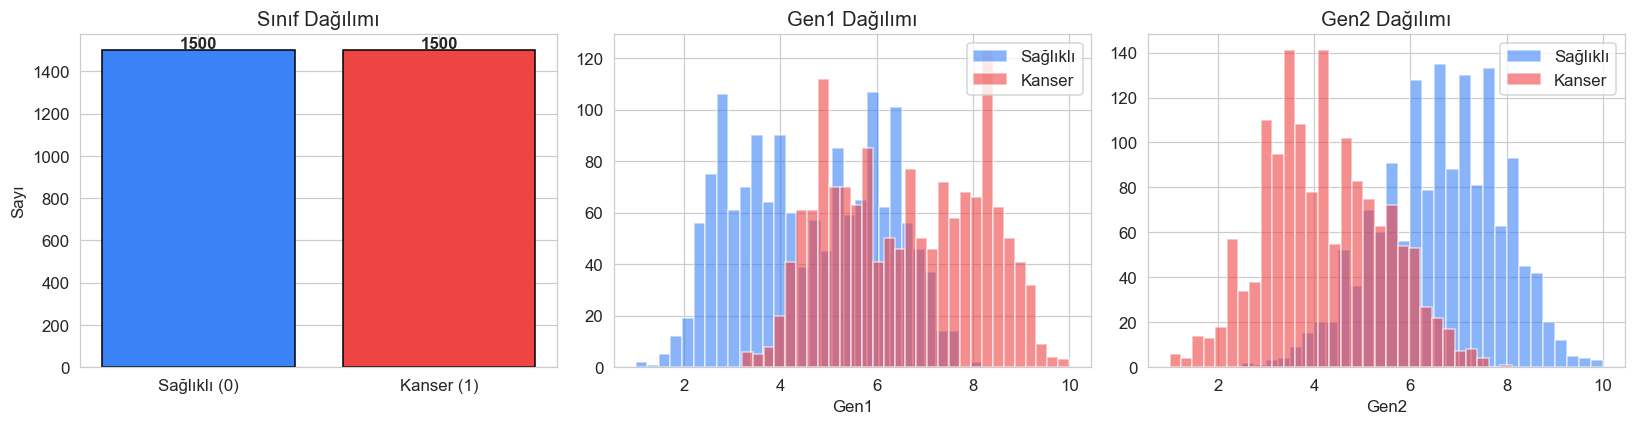

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sınıf dağılımı
counts = df['Kanser'].value_counts()
axes[0].bar(['Sağlıklı (0)', 'Kanser (1)'], counts.values, color=['#3B82F6', '#EF4444'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Sınıf Dağılımı')
axes[0].set_ylabel('Sayı')

# Gen1 dağılımı
axes[1].hist(df[df['Kanser']==0]['Gen1'], bins=30, alpha=0.6, label='Sağlıklı', color='#3B82F6')
axes[1].hist(df[df['Kanser']==1]['Gen1'], bins=30, alpha=0.6, label='Kanser', color='#EF4444')
axes[1].set_title('Gen1 Dağılımı')
axes[1].set_xlabel('Gen1')
axes[1].legend()

# Gen2 dağılımı
axes[2].hist(df[df['Kanser']==0]['Gen2'], bins=30, alpha=0.6, label='Sağlıklı', color='#3B82F6')
axes[2].hist(df[df['Kanser']==1]['Gen2'], bins=30, alpha=0.6, label='Kanser', color='#EF4444')
axes[2].set_title('Gen2 Dağılımı')
axes[2].set_xlabel('Gen2')
axes[2].legend()

plt.tight_layout()
plt.show()

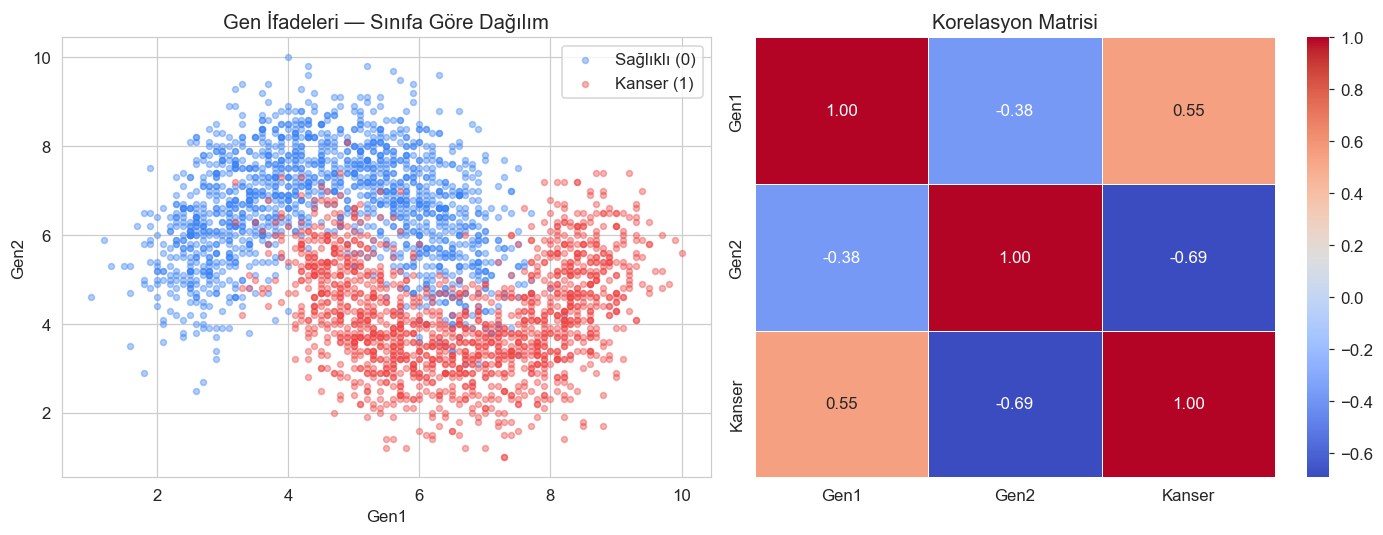

Korelasyon Tablosu:
         Gen1   Gen2  Kanser
Gen1    1.000 -0.375   0.546
Gen2   -0.375  1.000  -0.692
Kanser  0.546 -0.692   1.000


In [5]:
# Scatter plot: iki gen arasındaki ilişki
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

saglikli = df[df['Kanser']==0]
kanser    = df[df['Kanser']==1]

ax1.scatter(saglikli['Gen1'], saglikli['Gen2'], alpha=0.4, c='#3B82F6', s=15, label='Sağlıklı (0)')
ax1.scatter(kanser['Gen1'],   kanser['Gen2'],   alpha=0.4, c='#EF4444', s=15, label='Kanser (1)')
ax1.set_xlabel('Gen1')
ax1.set_ylabel('Gen2')
ax1.set_title('Gen İfadeleri — Sınıfa Göre Dağılım')
ax1.legend()

# Korelasyon matrisi
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, linewidths=0.5)
ax2.set_title('Korelasyon Matrisi')

plt.tight_layout()
plt.show()

print("Korelasyon Tablosu:")
print(corr.round(3))

## 4. Veri Ön İşleme

### 4.1 Neden Normalizasyon Gerekli?

Farklı ölçeklerdeki özellikler, mesafeye dayalı algoritmaları (KNN, K-Means) olumsuz etkiler. Örneğin Gen1 0–10 aralığında, Gen2 0–100 aralığında olsaydı KNN tamamen Gen2'ye odaklanırdı.

**StandardScaler (Z-score):** Her özelliği ortalaması 0, standart sapması 1 olacak şekilde dönüştürür.  
**MinMaxScaler:** Değerleri [0, 1] aralığına sıkıştırır.  

Bu projede **StandardScaler** kullanıyoruz.

In [6]:
# Özellikler ve hedef
X = df[['Gen1', 'Gen2']].values
y = df['Kanser'].values

# Eğitim / Test bölme (%80 / %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti  : {X_train.shape[0]} örnek")
print(f"Test seti    : {X_test.shape[0]} örnek")

# Normalizasyon — Scaler sadece eğitim seti üzerinde fit edilir!
# Test setine fit etmek 'data leakage' olur.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\nEğitim seti — Ölçeklemeden önce (ilk 3 örnek):")
print(X_train[:3])
print("\nEğitim seti — Ölçeklemeden sonra (ilk 3 örnek):")
print(X_train_sc[:3].round(3))

Eğitim seti  : 2400 örnek
Test seti    : 600 örnek

Eğitim seti — Ölçeklemeden önce (ilk 3 örnek):
[[5.9 3. ]
 [8.8 1.7]
 [3.5 6.6]]

Eğitim seti — Ölçeklemeden sonra (ilk 3 örnek):
[[ 0.168 -1.393]
 [ 1.75  -2.142]
 [-1.141  0.682]]


## 5. Aşırı Öğrenme, Bias-Varyans ve K-Fold

### 5.1 Aşırı Öğrenme (Overfitting) ve Öğrenememe (Underfitting)

**Overfitting (Aşırı Öğrenme):** Model eğitim verisini ezberler, test verisinde başarısız olur. Yüksek eğitim doğruluğu, düşük test doğruluğu gözlemlenir. Çok derin karar ağaçları tipik örnektir.

**Underfitting (Öğrenememe):** Model yeterince karmaşık değildir; hem eğitim hem test verisinde düşük başarı gösterir.

**Bias-Varyans Dengesi:**
- **Yüksek Bias** → Underfitting (model çok basit)
- **Yüksek Varyans** → Overfitting (model çok karmaşık)
- **Hedef:** İkisini dengede tutmak.

### 5.2 K-Fold Cross Validation

Veriyi tek seferinde bölmek yerine, K parçaya böleriz. Her seferinde 1 parça test, geri kalanlar eğitim olarak kullanılır. Bu sayede daha güvenilir bir performans tahmini elde ederiz.

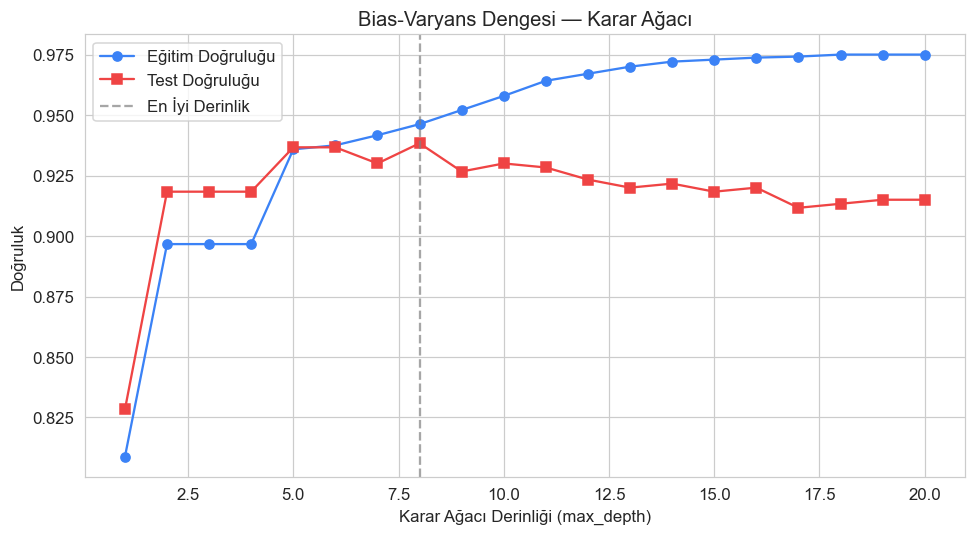

En yüksek test doğruluğu: 0.938 (derinlik=8)

Düşük derinlik  → Yüksek Bias (Underfitting)
Yüksek derinlik → Yüksek Varyans (Overfitting)


In [18]:
# Bias-Varyans gösterimi: Karar Ağacı derinliği değiştikçe eğitim/test hatası
depths = range(1, 21)
train_scores = []
test_scores  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_sc, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    test_scores.append(accuracy_score(y_test,  dt.predict(X_test_sc)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'o-', label='Eğitim Doğruluğu', color='#3B82F6')
plt.plot(depths, test_scores,  's-', label='Test Doğruluğu',   color='#EF4444')
plt.axvline(x=depths[test_scores.index(max(test_scores))], color='gray', linestyle='--', alpha=0.7, label='En İyi Derinlik')
plt.xlabel('Karar Ağacı Derinliği (max_depth)')
plt.ylabel('Doğruluk')
plt.title('Bias-Varyans Dengesi — Karar Ağacı')
plt.legend()
plt.tight_layout()
plt.show()

print(f"En yüksek test doğruluğu: {max(test_scores):.3f} (derinlik={depths[test_scores.index(max(test_scores))]})")
print()
print("Düşük derinlik  → Yüksek Bias (Underfitting)")
print("Yüksek derinlik → Yüksek Varyans (Overfitting)")

In [19]:
# K-Fold Cross Validation (K=5 ve K=10)
print("=" * 50)
print("K-FOLD CROSS VALIDATION SONUÇLARI")
print("=" * 50)

models_cv = {
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Karar Ağacı (d=5)':   DecisionTreeClassifier(max_depth=5, random_state=42),
    'Naive Bayes':         GaussianNB()
}

for k_fold in [5, 10]:
    print(f"\n{k_fold}-Fold:")
    skf = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=42)
    for name, model in models_cv.items():
        scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='accuracy')
        print(f"  {name:25s} → Ortalama: {scores.mean():.3f}  Std: {scores.std():.3f}")

K-FOLD CROSS VALIDATION SONUÇLARI

5-Fold:
  KNN (k=5)                 → Ortalama: 0.924  Std: 0.008
  Karar Ağacı (d=5)         → Ortalama: 0.918  Std: 0.014
  Naive Bayes               → Ortalama: 0.853  Std: 0.011

10-Fold:
  KNN (k=5)                 → Ortalama: 0.927  Std: 0.019
  Karar Ağacı (d=5)         → Ortalama: 0.923  Std: 0.019
  Naive Bayes               → Ortalama: 0.852  Std: 0.021


## 6. Model Eğitimi

Dört farklı algoritma kullanıyoruz:

| Model | Tür | Temel Fikir |
|:---|:---|:---|
| **KNN** | Mesafeye dayalı | En yakın K komşunun çoğunluk sınıfını atar |
| **Karar Ağacı** | Kural tabanlı | If-else kuralları ağacı oluşturur |
| **Naive Bayes** | Olasılıksal | Bayes teoremi + özellikler bağımsız varsayımı |
| **K-Means** | Kümeleme | Etiket kullanmaz, veriyi doğal kümelere ayırır |

> **Not:** K-Means bir kümeleme algoritmasıdır, doğrudan sınıflandırma yapmaz. Küme etiketleri ile gerçek etiketler eşleştirilerek değerlendirme yapılır.

In [30]:
# ---- KNN ----
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
y_prob_knn = knn.predict_proba(X_test_sc)[:, 1]

print("KNN eğitildi ✓")

# ---- Karar Ağacı ----
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)
y_prob_dt = dt.predict_proba(X_test_sc)[:, 1]

print("Karar Ağacı eğitildi ✓")

# ---- Naive Bayes ----
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)
y_prob_nb = nb.predict_proba(X_test_sc)[:, 1]

print("Naive Bayes eğitildi ✓")

# ---- K-Means (Kümeleme) ----
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_train_sc)
km_labels_raw = km.predict(X_test_sc)

# K-Means küme etiketleri 0/1 sırası rastgele olabilir; gerçek etiketlerle hizala
from scipy.stats import mode
km_mapping = {}
for cluster in [0, 1]:
    mask = km_labels_raw == cluster
    if mask.sum() > 0:
        km_mapping[cluster] = mode(y_test[mask], keepdims=True).mode[0]

y_pred_km = np.array([km_mapping[l] for l in km_labels_raw])
print("K-Means eğitildi ✓")

KNN eğitildi ✓
Karar Ağacı eğitildi ✓
Naive Bayes eğitildi ✓
K-Means eğitildi ✓


### 6.1 Karar Ağacı Görselleştirmesi

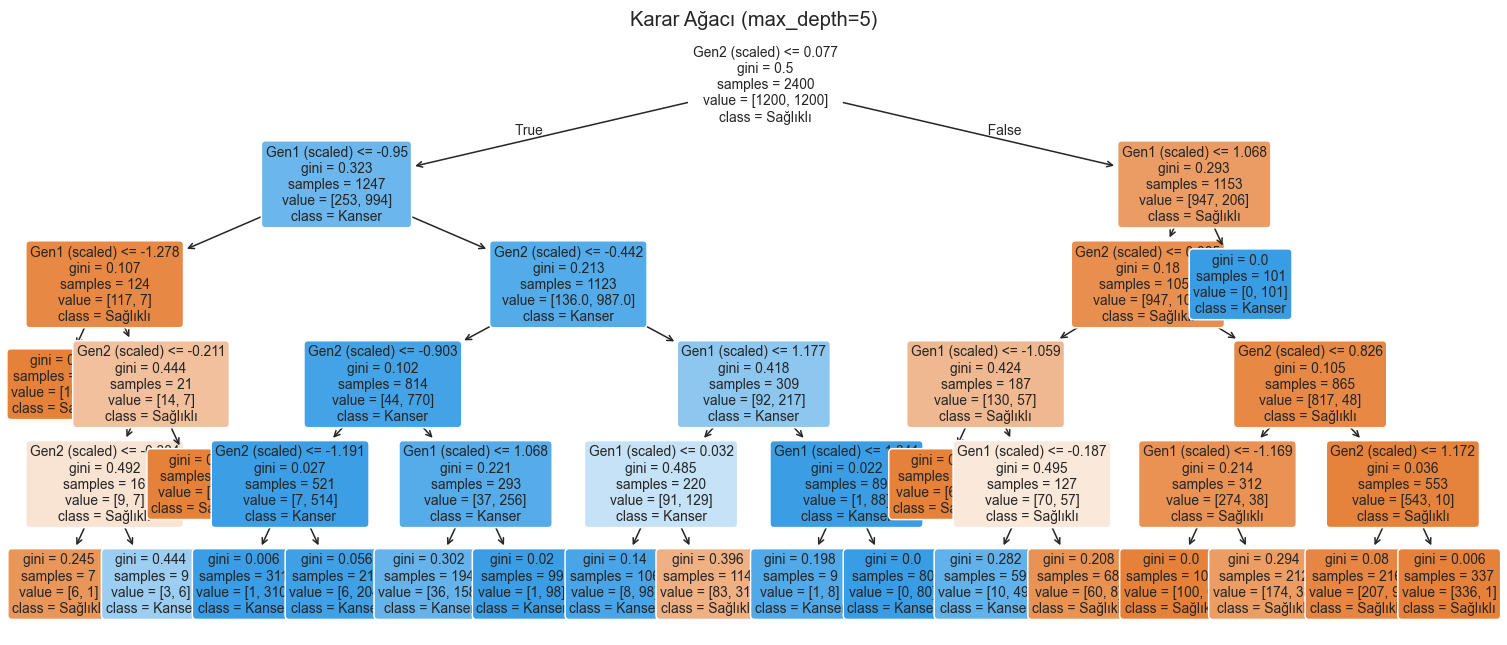

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt, feature_names=['Gen1 (scaled)', 'Gen2 (scaled)'],
          class_names=['Sağlıklı', 'Kanser'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Karar Ağacı (max_depth=5)')
plt.tight_layout()
plt.show()

### 6.2 K-Means Kümeleme Görselleştirmesi

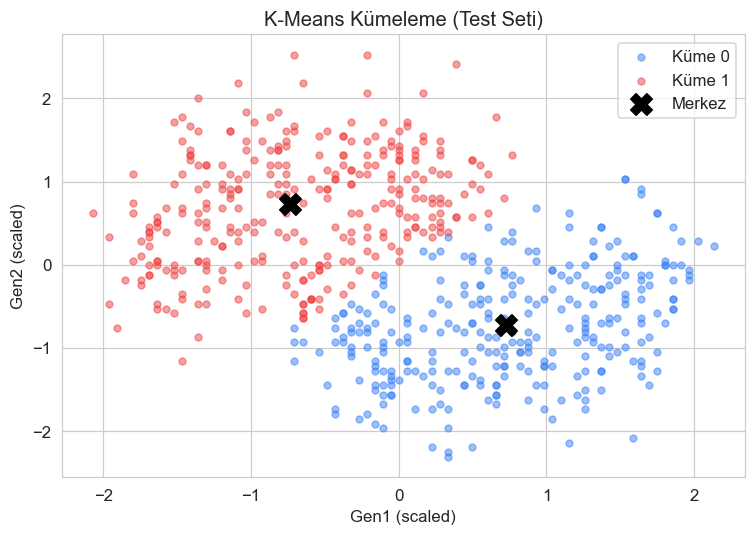

In [32]:
plt.figure(figsize=(7, 5))
colors_km = {0: '#3B82F6', 1: '#EF4444'}
for cluster in [0, 1]:
    mask = km.predict(X_test_sc) == cluster
    plt.scatter(X_test_sc[mask, 0], X_test_sc[mask, 1],
                c=colors_km[cluster], alpha=0.5, s=20, label=f'Küme {cluster}')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Merkez')
plt.xlabel('Gen1 (scaled)')
plt.ylabel('Gen2 (scaled)')
plt.title('K-Means Kümeleme (Test Seti)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Değerlendirme

### 7.1 Karmaşıklık Matrisi (Confusion Matrix)

Dört hücre bulunur:
- **TP (True Positive):** Gerçekte kanser, doğru tahmin edilmiş.
- **TN (True Negative):** Gerçekte sağlıklı, doğru tahmin edilmiş.
- **FP (False Positive):** Gerçekte sağlıklı, yanlışlıkla kanser dendi. (Type I Error)
- **FN (False Negative):** Gerçekte kanser, yanlışlıkla sağlıklı dendi. (Type II Error) — tıbbi açıdan en tehlikeli hata.

### 7.2 Performans Ölçütleri

| Metrik | Formül | Ne Ölçer? |
|:---|:---|:---|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Genel doğruluk |
| **Precision** | TP/(TP+FP) | Kanser dediğinde ne kadar doğru? |
| **Recall (Sensitivity)** | TP/(TP+FN) | Kanserlerin kaçını yakaladık? |
| **F1-Score** | 2·(P·R)/(P+R) | Precision ve Recall dengesi |

### 7.3 ROC Eğrisi ve AUC

ROC eğrisi, sınıflandırma eşiği değiştikçe True Positive Rate ile False Positive Rate'in nasıl değiştiğini gösterir. **AUC (Area Under Curve)** bu eğrinin altındaki alandır; 1'e ne kadar yakınsa model o kadar iyi.

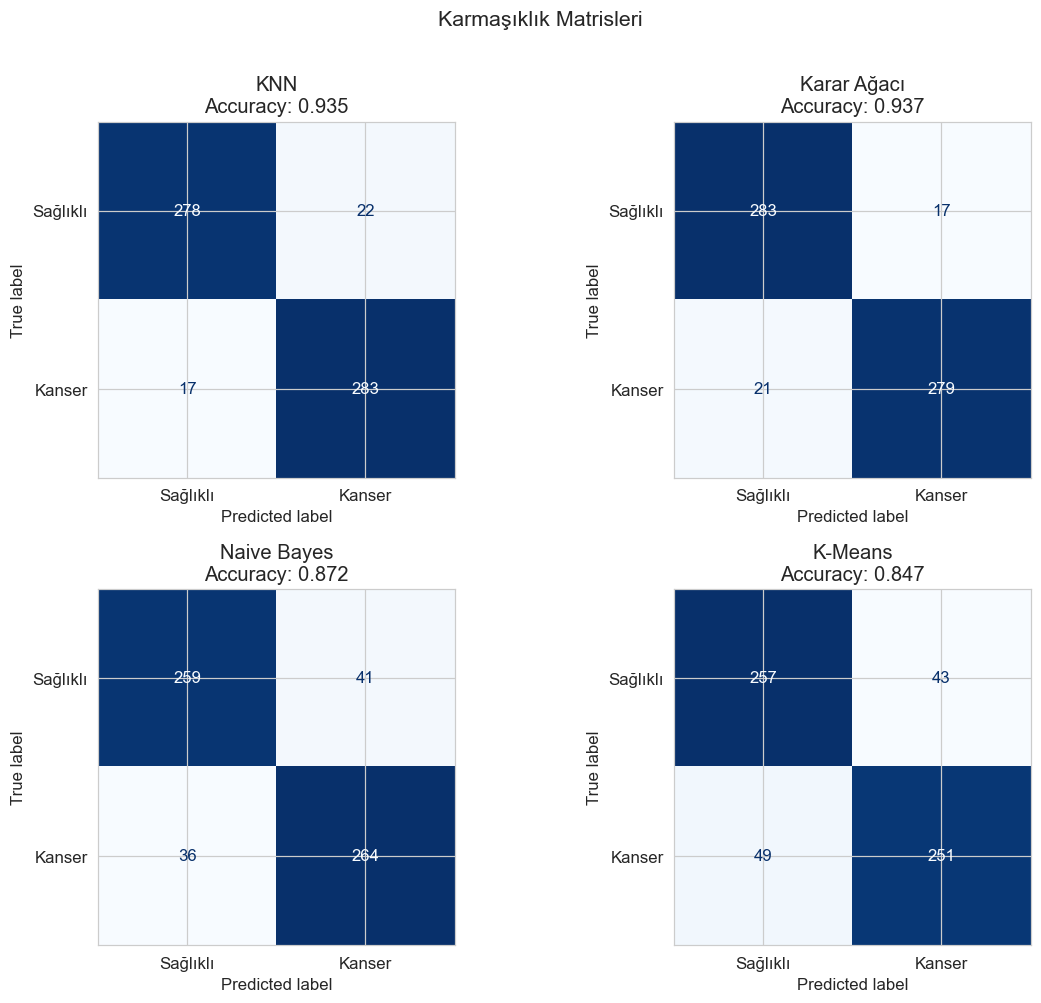

In [33]:
models_eval = {
    'KNN':          (y_pred_knn, y_prob_knn),
    'Karar Ağacı':  (y_pred_dt,  y_prob_dt),
    'Naive Bayes':  (y_pred_nb,  y_prob_nb),
    'K-Means':      (y_pred_km,  None)
}

# Karmaşıklık Matrisleri
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for i, (name, (y_pred, _)) in enumerate(models_eval.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sağlıklı', 'Kanser'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}')

plt.suptitle('Karmaşıklık Matrisleri', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
# Performans Raporu
print("=" * 55)
print("PERFORMANS ÖLÇÜTLERİ")
print("=" * 55)

summary = []
for name, (y_pred, _) in models_eval.items():
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    jacc = jaccard_score(y_test, y_pred)
    summary.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'Jaccard': jacc})
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Sağlıklı', 'Kanser']))

df_summary = pd.DataFrame(summary)
print("\n" + "=" * 55)
print("ÖZET TABLO")
print("=" * 55)
print(df_summary.round(3).to_string(index=False))

PERFORMANS ÖLÇÜTLERİ

--- KNN ---
              precision    recall  f1-score   support

    Sağlıklı       0.94      0.93      0.93       300
      Kanser       0.93      0.94      0.94       300

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.93       600
weighted avg       0.94      0.94      0.93       600


--- Karar Ağacı ---
              precision    recall  f1-score   support

    Sağlıklı       0.93      0.94      0.94       300
      Kanser       0.94      0.93      0.94       300

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600


--- Naive Bayes ---
              precision    recall  f1-score   support

    Sağlıklı       0.88      0.86      0.87       300
      Kanser       0.87      0.88      0.87       300

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       60

### 7.4 Benzerlik İndeksleri

**Jaccard İndeksi (Jaccard Similarity):** İki kümenin kesişiminin birleşimine oranıdır.  
`J = TP / (TP + FP + FN)`  
0 ile 1 arasında değer alır; 1 mükemmel eşleşme demektir.

In [35]:
print("Jaccard Benzerlik İndeksleri:")
print("-" * 35)
for name, (y_pred, _) in models_eval.items():
    j = jaccard_score(y_test, y_pred)
    print(f"  {name:15s}: {j:.4f}")

Jaccard Benzerlik İndeksleri:
-----------------------------------
  KNN            : 0.8789
  Karar Ağacı    : 0.8801
  Naive Bayes    : 0.7742
  K-Means        : 0.7318


### 7.5 ROC Eğrisi ve AUC

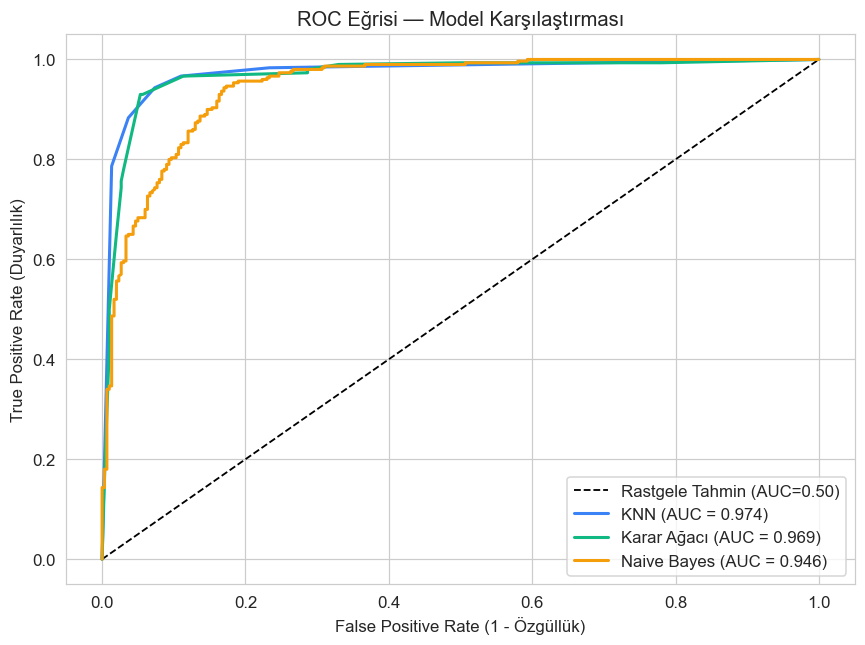

AUC Değerleri:
  KNN            : 0.9738
  Karar Ağacı    : 0.9688
  Naive Bayes    : 0.9462

Not: K-Means olasılık çıktısı üretmediğinden ROC hesaplanamaz.


In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Rastgele Tahmin (AUC=0.50)')

colors_roc = ['#3B82F6', '#10B981', '#F59E0B']
roc_models = [('KNN', y_prob_knn), ('Karar Ağacı', y_prob_dt), ('Naive Bayes', y_prob_nb)]

for (name, y_prob), color in zip(roc_models, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

ax.set_xlabel('False Positive Rate (1 - Özgüllük)')
ax.set_ylabel('True Positive Rate (Duyarlılık)')
ax.set_title('ROC Eğrisi — Model Karşılaştırması')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("AUC Değerleri:")
for name, y_prob in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    print(f"  {name:15s}: {auc(fpr,tpr):.4f}")
print("\nNot: K-Means olasılık çıktısı üretmediğinden ROC hesaplanamaz.")

## 8. Dengesiz Sınıflar

### Dengesiz Sınıf Nedir?

Veri setinde bir sınıfın diğerine oranla çok daha fazla temsil edildiği durumlardır. Örneğin 1000 kayıttan 950'si sağlıklı, 50'si kanser ise model her zaman "sağlıklı" diyerek %95 accuracy elde edebilir; bu yanıltıcıdır.

**Bu projede** sınıf dağılımı tam olarak dengeli (%50-%50). Ancak gerçek tıbbi veri setlerde kanser vakaları nadiren bu kadar dengeli olur. Aşağıda yapay dengesizlik yaratarak sorunu gösteriyoruz.

**Çözümler:**
- **Oversampling (SMOTE):** Azınlık sınıfından yapay örnekler üretir.
- **Undersampling:** Çoğunluk sınıfından örnek siler.
- **class_weight='balanced':** Model içi ağırlıklandırma.

In [37]:
# Dengeli ve dengesiz veri karşılaştırması
np.random.seed(42)

# Yapay dengesiz veri: %20 kanser, %80 sağlıklı
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
idx_1_small = np.random.choice(idx_1, size=len(idx_1)//4, replace=False)
idx_imb = np.concatenate([idx_0, idx_1_small])
X_imb, y_imb = X[idx_imb], y[idx_imb]

print(f"Dengeli veri    → Sağlıklı: {(y==0).sum()}, Kanser: {(y==1).sum()}")
print(f"Dengesiz veri   → Sağlıklı: {(y_imb==0).sum()}, Kanser: {(y_imb==1).sum()}")

# Her iki durumda model eğit
for label, Xi, yi in [("Dengeli", X, y), ("Dengesiz", X_imb, y_imb)]:
    Xtr, Xte, ytr, yte = train_test_split(Xi, yi, test_size=0.2, random_state=42, stratify=yi)
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc  = sc.transform(Xte)
    
    m = KNeighborsClassifier(n_neighbors=5)
    m.fit(Xtr_sc, ytr)
    yp = m.predict(Xte_sc)
    
    print(f"\n--- {label} Veri — KNN ---")
    print(f"  Accuracy: {accuracy_score(yte, yp):.3f}")
    print(f"  F1-Score: {f1_score(yte, yp, zero_division=0):.3f}")
    print(f"  Jaccard : {jaccard_score(yte, yp, zero_division=0):.3f}")

print("\n→ Dengesiz veride Accuracy yüksek ama F1-Score çok düşük. Bu yanıltıcıdır!")

Dengeli veri    → Sağlıklı: 1500, Kanser: 1500
Dengesiz veri   → Sağlıklı: 1500, Kanser: 375

--- Dengeli Veri — KNN ---
  Accuracy: 0.935
  F1-Score: 0.936
  Jaccard : 0.879

--- Dengesiz Veri — KNN ---
  Accuracy: 0.952
  F1-Score: 0.875
  Jaccard : 0.778

→ Dengesiz veride Accuracy yüksek ama F1-Score çok düşük. Bu yanıltıcıdır!


## 9. Sonuç ve Karşılaştırma

In [38]:
# Final karşılaştırma tablosu
print("=" * 60)
print("MODELLER — FINAL KARŞILAŞTIRMA")
print("=" * 60)

results = []
for name, (y_pred, y_prob) in models_eval.items():
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    jacc = jaccard_score(y_test, y_pred)
    auc_val = '-'
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = f"{auc(fpr,tpr):.3f}"
    results.append([name, f"{acc:.3f}", f"{f1:.3f}", f"{jacc:.3f}", auc_val])

df_res = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1-Score', 'Jaccard', 'AUC'])
print(df_res.to_string(index=False))

print("\n→ En yüksek AUC değerine sahip model en iyi sınıflandırıcıdır.")
print("→ K-Means kümeleme algoritmasıdır; sınıflandırma metriklerinde dezavantajlıdır.")

MODELLER — FINAL KARŞILAŞTIRMA
      Model Accuracy F1-Score Jaccard   AUC
        KNN    0.935    0.936   0.879 0.974
Karar Ağacı    0.937    0.936   0.880 0.969
Naive Bayes    0.872    0.873   0.774 0.946
    K-Means    0.847    0.845   0.732     -

→ En yüksek AUC değerine sahip model en iyi sınıflandırıcıdır.
→ K-Means kümeleme algoritmasıdır; sınıflandırma metriklerinde dezavantajlıdır.


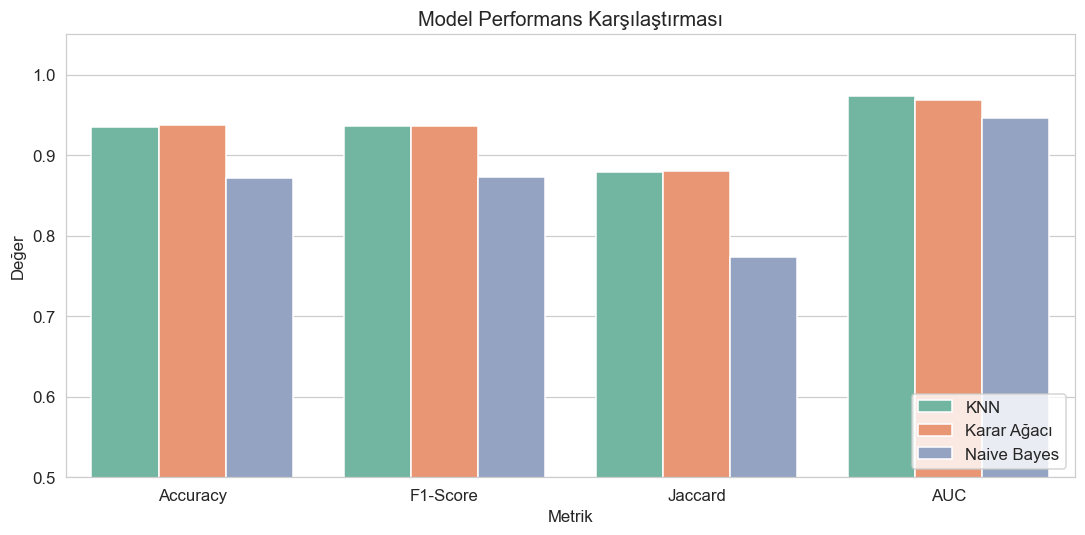

In [39]:
# Görsel karşılaştırma
df_plot = df_res[df_res['AUC'] != '-'].copy()
df_plot[['Accuracy','F1-Score','Jaccard']] = df_plot[['Accuracy','F1-Score','Jaccard']].astype(float)
df_plot['AUC'] = df_plot['AUC'].astype(float)

df_melt = df_plot.melt(id_vars='Model', value_vars=['Accuracy','F1-Score','Jaccard','AUC'],
                        var_name='Metrik', value_name='Değer')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melt, x='Metrik', y='Değer', hue='Model', palette='Set2')
plt.ylim(0.5, 1.05)
plt.title('Model Performans Karşılaştırması')
plt.ylabel('Değer')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 9.1 Genel Değerlendirme

Bu projede gen ifadesi verileri üzerinde dört farklı makine öğrenmesi algoritması uygulandı.

- **KNN:** Mesafe tabanlı, basit ve yorumlanabilir. K değeri doğruluğu etkiler.
- **Karar Ağacı:** Kural tabanlı, görsel olarak yorumlanabilir. Derin ağaçlarda overfitting riski yüksektir.
- **Naive Bayes:** Hızlı ve olasılıksal. Özellikler arası bağımsızlık varsayımı her zaman gerçekçi değildir.
- **K-Means:** Gözetimsiz bir algoritma olduğundan sınıflandırma problemlerinde sınırlı kullanım alanı vardır.

Bias-Varyans analizi, karar ağacında derin yapıların overfitting yarattığını ortaya koymuştur. K-Fold cross validation ile daha güvenilir performans tahminleri elde edilmiştir. Dengesiz sınıf örneğinde Accuracy'nin yanıltıcı olabileceği, F1-Score ve AUC gibi ölçütlerin daha bilgilendirici olduğu gözlemlenmiştir.

---

## 10. Kaynakça

1. Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly Media.
2. Scikit-learn Documentation. https://scikit-learn.org/stable/
3. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
4. He, H., & Garcia, E. A. (2009). Learning from Imbalanced Data. *IEEE TKDE*.
